# Phase 5 — Out-of-Sample Evaluation

**Purpose:** This notebook is *evidentiary*, not exploratory. Every prior phase reported a *point*
Sharpe from a *single* full-window pass. Phase 5 is the honest evaluator: it selects the F7
hyperparameters **leak-free**, reports the verdict on data the selection **never saw**, and attaches
a **confidence interval** to every number. Its finding overturns the tidy point comparisons of
Phases 4B–4C — which is exactly what a rigorous out-of-sample evaluation exists to do.

## The honest-selection architecture

```
|<-------------- train + validation -------------->|<--- frozen test --->|
|  purged K-Fold selects ML hyperparameters (by IC) |                     |
|  validation OOS tail selects the portfolio levers |   the verdict is    |
|            (by net Sharpe, per model)             |  measured only here |
```

Two objectives, **two tools** (the deliberate methodology call):
- **ML prediction hyperparameters** (RF/XGB depth/leaf/lr) are an IID-ish labeled-sample problem →
  **purged + embargoed K-Fold**, scored by **information coefficient** (Spearman rank-corr of
  predicted vs. realized returns — for a *signal*, the ordering is what must generalize).
- **Portfolio levers** (`shrinkage_weight`, per-model `turnover_penalty`) are a *net-Sharpe over a
  return time series* objective → **validation-segment net Sharpe** through the real engine. K-Fold
  here would be a category error (portfolio returns are dependent, not exchangeable).

| Problem | What this notebook shows |
|---------|--------------------------|
| **P4** | The whole phase is P4: purged CV (§2 visual), a frozen held-out test (§3), block-bootstrap CIs (§3), and a Deflated Sharpe that counts the *whole* search (§4). |

**Reproducibility.** This notebook reads `data/gold/phase5_results.json` and
`dsr_trial_ledger.json` — the exact artifacts `src/run_phase5.py` wrote on live Gold, regenerable
with `dvc repro phase5_compare`. The ~43-min selection+backtest pipeline is not re-run inline; the
DVC stage, the artifacts, and `tests/test_purged_kfold.py` (the leakage gate) are the reproducibility
guarantee. The purge/embargo visualization in §2 is generated live from the real `PurgedKFold`.

> ## ⚠️ Re-executed under the Phase 2 validation protocol
>
> Model selection is now **strictly forward-only**: training always precedes the validation
> window, separated by a purge and an embargo. The earlier runs used purged K-fold, which trains
> on every date outside the purge band — *including dates after the validation fold*. That is the
> canonical López de Prado construction and is defensible when labels overlap, but it scores a
> 2018 fold with a model partly fitted on 2019–2024, which is not a question a live allocator can
> ask.
>
> Two consequences run through everything below:
>
> 1. **Comparative claims now rest on paired tests**, not on marginal confidence intervals.
>    Overlapping marginal intervals do not establish equivalence, and non-overlapping ones do not
>    establish a difference — §4 tests the difference directly.
> 2. **No number is typed into this notebook.** Every figure is read from the committed artifacts
>    (`phase5_results.json`, `phase5_validation_protocol.json`, `paired_comparison_results.json`,
>    `dsr_trial_ledger.json`), so a re-run cannot leave stale prose behind. Where a value appears
>    in text below, it is printed by the cell above it.


## 1. Setup — load the committed Phase 5 artifacts (P4)

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

NB_CWD = Path.cwd()
ROOT = NB_CWD.parent if (NB_CWD.parent / "data").exists() else NB_CWD
sys.path.insert(0, str(ROOT / "src"))
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

GOLD = ROOT / "data" / "gold"
RESULTS  = json.loads((GOLD / "phase5_results.json").read_text())
PROTOCOL = json.loads((GOLD / "phase5_validation_protocol.json").read_text())
PAIRED   = json.loads((GOLD / "paired_comparison_results.json").read_text())
# Ledger schema 2: {"schema_version": 2, "trials": {universe: [ {...}, ... ]}}
LEDGER   = json.loads((GOLD / "dsr_trial_ledger.json").read_text())["trials"]

for uni, e in RESULTS.items():
    s = e["search_ledger"]
    print(f"{uni}: train+val {e['train_val_start']}→{e['train_val_end']} | "
          f"frozen test {e['test_start']}→{e['test_end']}")
    print(f"    protocol={e['validation_protocol']} | search N={s['n_trials_total']} "
          f"{s['n_by_kind']} | {s['n_with_sharpe']} carry a Sharpe")


etf_2017: train+val 2004-11-19→2018-12-21 | frozen test 2018-12-24→2026-07-24
    protocol=purged_walk_forward_expanding | search N=51 {'ml_grid': 15, 'lever': 36} | 36 carry a Sharpe
full_2021: train+val 2021-07-02→2024-10-16 | frozen test 2024-10-17→2026-07-24
    protocol=purged_walk_forward_expanding | search N=51 {'ml_grid': 15, 'lever': 36} | 36 carry a Sharpe


## 2. Forward-only selection, and what it replaced (P4)

Both splitters are run below on the same synthetic date axis, so the difference is visible rather
than asserted. **Red** = validation, **grey** = purged/embargoed out of training, **blue** =
training.

Look at the first fold of each. `PurgedKFold` (top) paints blue to the *right* of the red block:
it trains on the future. `PurgedWalkForwardSplit` (bottom) never does — training is always the
prefix that precedes the validation window.


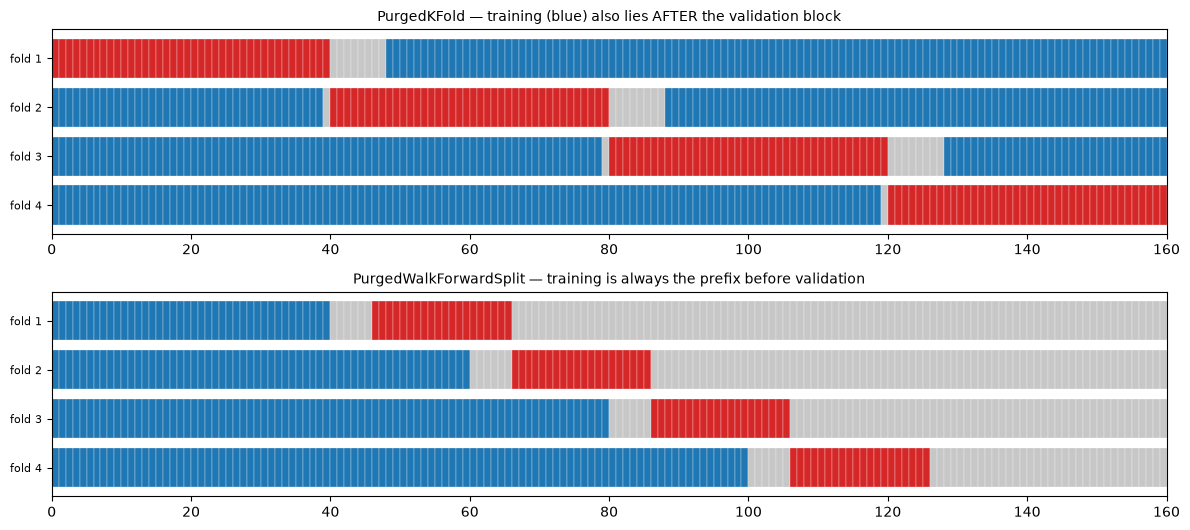

In [2]:
from purged_kfold import PurgedKFold, PurgedWalkForwardSplit, _sample_dates

demo_dates = pd.bdate_range("2021-01-04", periods=160, name="Date")
demo = pd.DataFrame({"x": range(len(demo_dates))}, index=demo_dates)

def draw(ax, splitter, title):
    for fold, (train_idx, val_idx) in enumerate(splitter.split(demo)):
        train_d, val_d = set(_sample_dates(demo)[train_idx]), set(_sample_dates(demo)[val_idx])
        for i, d in enumerate(demo_dates):
            c = "tab:red" if d in val_d else ("tab:blue" if d in train_d else "0.78")
            ax.barh(fold, 1, left=i, color=c, edgecolor="white", linewidth=0.2)
    ax.set_title(title, fontsize=10)
    ax.set_xlim(0, len(demo_dates)); ax.invert_yaxis()
    ax.set_yticks(range(4)); ax.set_yticklabels([f"fold {i+1}" for i in range(4)], fontsize=8)

fig, (a1, a2) = plt.subplots(2, 1, figsize=(12, 5.4))
draw(a1, PurgedKFold(n_splits=4, embargo_frac=0.05, label_horizon=1),
     "PurgedKFold — training (blue) also lies AFTER the validation block")
draw(a2, PurgedWalkForwardSplit(min_train_dates=40, val_dates=20, n_splits=4,
                                embargo_dates=5, label_horizon=1),
     "PurgedWalkForwardSplit — training is always the prefix before validation")
plt.tight_layout(); plt.show()


`tests/test_purged_kfold.py` asserts the forward-only property on real dates — and asserts that
`PurgedKFold` *would fail* the same check, so the reason for keeping two splitters stays visible.
`PurgedKFold` is retained and still tested; it did not change meaning, the caller changed tool.

The realised geometry of the run below is not illustrative — it is published in
`phase5_validation_protocol.json` and printed next.


### The folds this run actually used

Read from the artifact, not from the configuration — so this shows what happened, not what was
intended. The final column is the check that matters: training must end strictly before validation
begins.


In [3]:
rows = []
for uni, per_model in PROTOCOL["universes"].items():
    for model_type, block in per_model.items():
        for f in block["folds"]:
            rows.append({
                "universe": uni, "model": model_type, "fold": f["fold"],
                "train": f"{f['train_start']}→{f['train_end']}",
                "val": f"{f['val_start']}→{f['val_end']}",
                "train_rows": f["n_train_rows"], "val_rows": f["n_val_rows"],
                "train<val": f["train_end"] < f["val_start"],
            })
folds = pd.DataFrame(rows)
print(f"forward-only holds on every fold: {bool(folds['train<val'].all())}  "
      f"({len(folds)} folds across {folds['universe'].nunique()} universes × "
      f"{folds['model'].nunique()} models)")
print(f"config: {PROTOCOL['config']}")
display(folds[folds.universe == folds.universe.iloc[0]].head(10))

# Per-fold IC of the SELECTED configuration — a mean hides whether the signal is
# steady or carried by one fold.
for uni, per_model in PROTOCOL["universes"].items():
    for model_type, block in per_model.items():
        ics = block["fold_ics_of_selected"]
        print(f"{uni:10s} {model_type:14s} mean IC {block['mean_ic_of_selected']:+.4f}  "
              f"per fold {[round(v, 4) for v in ics]}")


forward-only holds on every fold: True  (20 folds across 2 universes × 2 models)
config: {'min_train_dates': 378, 'val_dates': 63, 'n_splits': 5, 'embargo_dates': 5, 'label_horizon': 1, 'mode': 'expanding', 'step_dates': None}


,universe,model,fold,train,val,train_rows,val_rows,train<val
0,etf_2017,random_forest,1,2005-02-15→2006-07-27,2006-08-07→2006-11-01,1890,315,True
1,etf_2017,random_forest,2,2005-02-15→2006-10-24,2006-11-02→2007-01-29,2205,315,True
2,etf_2017,random_forest,3,2005-02-15→2007-01-19,2007-01-30→2007-04-26,2520,315,True
3,etf_2017,random_forest,4,2005-02-15→2007-04-18,2007-04-27→2007-07-24,2835,315,True
4,etf_2017,random_forest,5,2005-02-15→2007-07-16,2007-07-25→2007-10-19,3150,315,True
5,etf_2017,xgboost,1,2005-02-15→2006-07-27,2006-08-07→2006-11-01,1890,315,True
6,etf_2017,xgboost,2,2005-02-15→2006-10-24,2006-11-02→2007-01-29,2205,315,True
7,etf_2017,xgboost,3,2005-02-15→2007-01-19,2007-01-30→2007-04-26,2520,315,True
8,etf_2017,xgboost,4,2005-02-15→2007-04-18,2007-04-27→2007-07-24,2835,315,True
9,etf_2017,xgboost,5,2005-02-15→2007-07-16,2007-07-25→2007-10-19,3150,315,True


etf_2017   random_forest  mean IC +0.0671  per fold [0.1092, -0.0184, 0.0821, 0.0531, 0.1098]
etf_2017   xgboost        mean IC +0.1144  per fold [0.1393, -0.0196, 0.1135, 0.1471, 0.1919]
full_2021  random_forest  mean IC -0.0316  per fold [-0.0117, -0.057, -0.0321, -0.0319, -0.0253]
full_2021  xgboost        mean IC +0.0117  per fold [0.0163, -0.0023, -0.0059, -0.0337, 0.0842]


## 3. The held-out verdict — with error bars (P4)

Each strategy's **test-segment** net Sharpe (a window the selection never saw) with its
**block-bootstrap 90% CI**. These intervals are *marginal* — each describes one strategy on its own.
Read them as uncertainty quantification, and nothing more: whether two strategies actually differ is
a separate question, tested in §4.

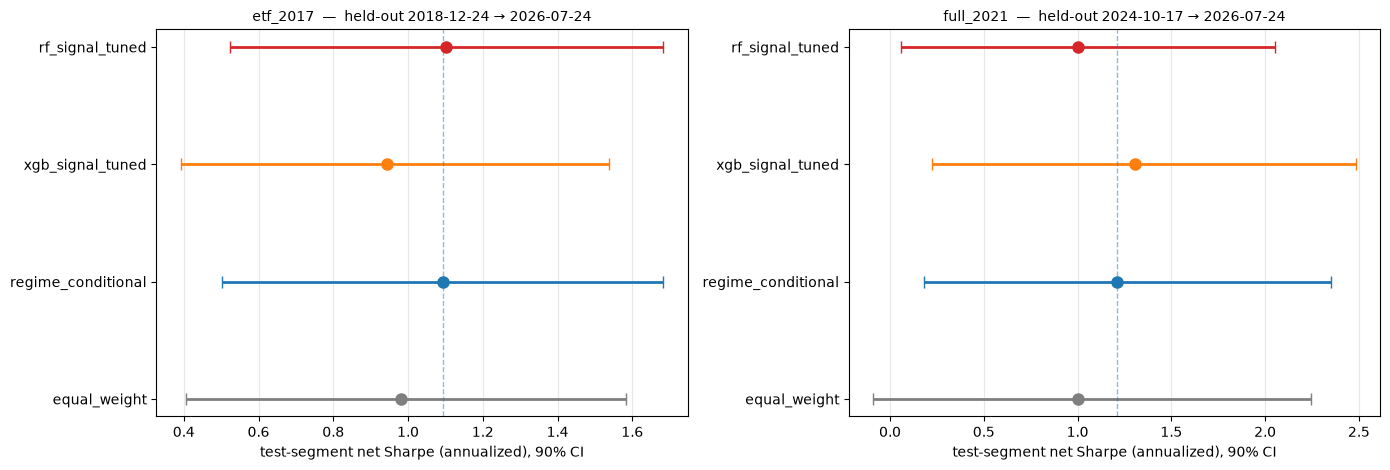

In [4]:
ORDER = ["rf_signal_tuned", "xgb_signal_tuned", "regime_conditional", "equal_weight"]
COLORS = {"rf_signal_tuned": "tab:red", "xgb_signal_tuned": "tab:orange",
          "regime_conditional": "tab:blue", "equal_weight": "tab:gray"}

def rows(universe):
    e = RESULTS[universe]
    merged = {**e["tuned"], **e["baselines"]}
    out = []
    for name in ORDER:
        m = merged[name]
        lo, hi = m["test_sharpe_ci"]
        out.append((name, m["test_sharpe_net"], lo, hi))
    return out

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
for ax, uni in zip(axes, ["etf_2017", "full_2021"]):
    data = rows(uni)
    for i, (name, pt, lo, hi) in enumerate(data):
        ax.errorbar(pt, i, xerr=[[pt - lo], [hi - pt]], fmt="o", color=COLORS[name],
                    capsize=4, markersize=8, elinewidth=2)
    hurdle = RESULTS[uni]["hurdle_on_test"]["test_sharpe_net"]
    ax.axvline(hurdle, ls="--", color="tab:blue", alpha=0.5, lw=1)
    ax.set_yticks(range(len(data))); ax.set_yticklabels([d[0] for d in data])
    ax.invert_yaxis()
    ax.set_xlabel("test-segment net Sharpe (annualized), 90% CI")
    ax.set_title(f"{uni}  —  held-out {RESULTS[uni]['test_start']} → {RESULTS[uni]['test_end']}",
                 fontsize=10)
    ax.grid(alpha=0.3, axis="x")
plt.tight_layout(); plt.show()

In [5]:
for uni in ["etf_2017", "full_2021"]:
    e = RESULTS[uni]
    merged = {**e["tuned"], **e["baselines"]}
    print(f"=== {uni} — held-out test verdict ===")
    for name in ORDER:
        m = merged[name]; lo, hi = m["test_sharpe_ci"]
        star = "  ← best tuned" if name == e["best_tuned"] else (
               "  ← hurdle" if name == "regime_conditional" else "")
        print(f"  {name:20} {m['test_sharpe_net']:+.4f}   90% CI [{lo:+.3f}, {hi:+.3f}]{star}")
    print(f"  VERDICT: best tuned beats hurdle on test = {e['beats_hurdle_on_test']}  "
          f"(all CIs overlap → not statistically significant)")
    print()

=== etf_2017 — held-out test verdict ===
  rf_signal_tuned      +1.1020   90% CI [+0.525, +1.683]  ← best tuned
  xgb_signal_tuned     +0.9440   90% CI [+0.391, +1.537]
  regime_conditional   +1.0934   90% CI [+0.502, +1.682]  ← hurdle
  equal_weight         +0.9821   90% CI [+0.406, +1.583]
  VERDICT: best tuned beats hurdle on test = True  (all CIs overlap → not statistically significant)

=== full_2021 — held-out test verdict ===
  rf_signal_tuned      +1.0012   90% CI [+0.059, +2.055]
  xgb_signal_tuned     +1.3084   90% CI [+0.224, +2.484]  ← best tuned
  regime_conditional   +1.2128   90% CI [+0.182, +2.349]  ← hurdle
  equal_weight         +1.0027   90% CI [-0.090, +2.243]
  VERDICT: best tuned beats hurdle on test = True  (all CIs overlap → not statistically significant)



**Reading the intervals — and what they cannot tell you.** These are *marginal* intervals: each
describes the uncertainty of one strategy on its own. Their overlap is **not** a test of whether two
strategies differ, and neither is their non-overlap. Concluding "statistically indistinguishable"
from overlap is the same unlicensed inference as concluding "superior" from non-overlap — earlier
versions of this notebook made the first mistake.

The difference is tested in §4. Everything above is descriptive.


## 4. The paired test — the evidence a comparative claim requires (P4)

A paired moving-block bootstrap on the **same** frozen-test dates, net of costs. Both series are
resampled with the *same* block indices, so each draw keeps the two strategies on the same calendar
days — preserving serial dependence within each and same-day correlation between them, which is the
variance reduction that makes the paired test more powerful than comparing two marginal intervals.

The p-value is **null-centred**: the resampled differences are recentred on zero to simulate "no
outperformance", and the p-value is the share of that null distribution at or beyond the *observed*
difference. It is not the raw fraction of draws above zero — that is reported separately as
`prob_sharpe_diff_positive` and must never be presented as a p-value.


,universe,candidate,benchmark,sharpe_diff,sharpe_diff_ci,ann_return_diff,p_value_no_outperformance,prob_sharpe_diff_positive,ci_spans_zero
0,etf_2017,rf_signal_tuned,regime_conditional,0.0087,"[-0.025097, 0.040947]",0.0027,0.3258,0.6580,True
1,etf_2017,rf_signal_tuned,equal_weight,0.1199,"[-0.013074, 0.24747]",0.0086,0.0660,0.9325,True
2,etf_2017,xgb_signal_tuned,regime_conditional,-0.1494,"[-0.308359, 0.010087]",-0.0125,0.9385,0.0590,True
3,etf_2017,xgb_signal_tuned,equal_weight,-0.0381,"[-0.176841, 0.09607]",-0.0066,0.6712,0.3155,True
4,full_2021,rf_signal_tuned,regime_conditional,-0.2116,"[-0.550915, 0.150667]",0.0027,0.8496,0.1680,True
5,full_2021,rf_signal_tuned,equal_weight,-0.0015,"[-0.374485, 0.35951]",0.0174,0.5122,0.4940,True
6,full_2021,xgb_signal_tuned,regime_conditional,0.0956,"[-0.314688, 0.541015]",0.0390,0.3608,0.6565,True
7,full_2021,xgb_signal_tuned,equal_weight,0.3056,"[-0.158167, 0.783656]",0.0537,0.1469,0.8650,True



comparisons: 8 | establishing outperformance: 0
p-value range: 0.066 to 0.939
multiple-testing correction: not_established


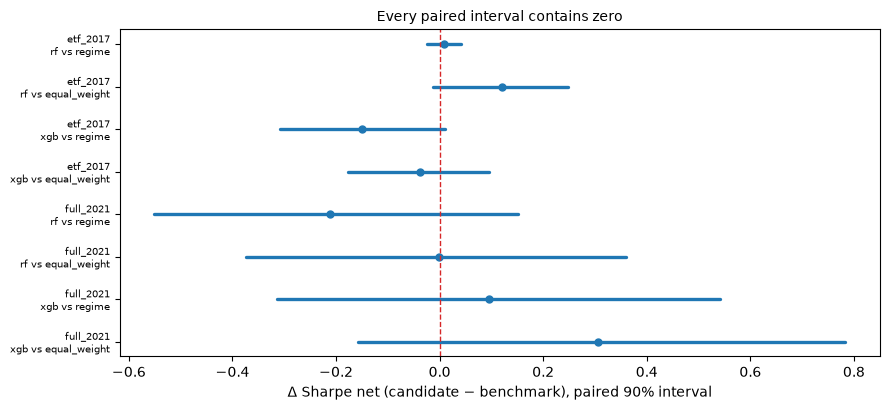

In [6]:
cmp_df = pd.DataFrame(PAIRED["comparisons"])[[
    "universe", "candidate", "benchmark", "sharpe_diff", "sharpe_diff_ci",
    "ann_return_diff", "p_value_no_outperformance", "prob_sharpe_diff_positive",
]]
cmp_df["ci_spans_zero"] = cmp_df["sharpe_diff_ci"].apply(lambda c: c[0] <= 0 <= c[1])
display(cmp_df)

n_sig = int((~cmp_df["ci_spans_zero"] & (cmp_df["p_value_no_outperformance"] < 0.05)).sum())
print(f"\ncomparisons: {len(cmp_df)} | establishing outperformance: {n_sig}")
print(f"p-value range: {cmp_df['p_value_no_outperformance'].min():.3f} "
      f"to {cmp_df['p_value_no_outperformance'].max():.3f}")
print(f"multiple-testing correction: {PAIRED['multiple_testing']['status']}")

fig, ax = plt.subplots(figsize=(9, 4.2))
lab = cmp_df.apply(lambda r: f"{r.universe}\n{r.candidate.replace('_signal_tuned','')} vs "
                             f"{r.benchmark.replace('_conditional','')}", axis=1)
for k, (_, r) in enumerate(cmp_df.iterrows()):
    lo, hi = r["sharpe_diff_ci"]
    ax.plot([lo, hi], [k, k], color="tab:blue", lw=2.4, solid_capstyle="round")
    ax.plot([r["sharpe_diff"]], [k], "o", color="tab:blue", ms=5)
ax.axvline(0, color="tab:red", ls="--", lw=1)
ax.set_yticks(range(len(cmp_df))); ax.set_yticklabels(lab, fontsize=7.5)
ax.invert_yaxis(); ax.set_xlabel("Δ Sharpe net (candidate − benchmark), paired 90% interval")
ax.set_title("Every paired interval contains zero", fontsize=10)
plt.tight_layout(); plt.show()


**What the cell above prints.** Every interval contains zero, and the count of comparisons
establishing outperformance is zero. The reading is **"no evidence of outperformance"**, not
"equivalence": failing to reject is not accepting the null, and establishing equivalence would
require a test against a pre-specified margin, which was not run.

Worth isolating, because it is exactly what this test exists to catch: on one universe the tuned
XGB *beats* the regime baseline on point estimate — and `phase5_results.json` records it as such —
while the paired p-value sits far from any threshold. The point ranking is not supported.


## 5. What was selected, and how much the search could have flattered it (P4)


In [7]:
sel_rows = []
for uni, e in RESULTS.items():
    for name, t in e["tuned"].items():
        lv = t["selected_levers"]
        sel_rows.append({
            "universe": uni, "model": name,
            "ml_params": str(t["selected_ml_params"]),
            "shrinkage_weight": lv["shrinkage_weight"],
            "turnover_penalty": lv["turnover_penalty"],
            "cv_information_coeff": t["best_cv_ic"],
            "test_sharpe": t["test_sharpe_net"],
        })
pd.DataFrame(sel_rows).set_index(["universe", "model"])

ml_params  \
universe  model                                                                 
etf_2017  rf_signal_tuned   {'max_depth': 6, 'min_samples_leaf': 20, 'n_es...   
          xgb_signal_tuned  {'max_depth': 4, 'learning_rate': 0.05, 'n_est...   
full_2021 rf_signal_tuned   {'max_depth': 3, 'min_samples_leaf': 10, 'n_es...   
          xgb_signal_tuned  {'max_depth': 4, 'learning_rate': 0.1, 'n_esti...   

                            shrinkage_weight  turnover_penalty  \
universe  model                                                  
etf_2017  rf_signal_tuned             0.2500            0.0000   
          xgb_signal_tuned            1.0000            0.5000   
full_2021 rf_signal_tuned             0.5000            1.0000   
          xgb_signal_tuned            0.2500            2.0000   

                            cv_information_coeff  test_sharpe  
universe  model                                                
etf_2017  rf_signal_tuned                 0.0671       1.1020  
          xgb_signal_tuned                0.1144       0.9440  
full_2021 rf_signal_tuned                -0.0316       1.0012  
          xgb_signal_tuned                0.0117       1.3084

etf_2017   N total  51 {'ml_grid': 15, 'lever': 36} | 36 carry a Sharpe | reported DSR 0.986
full_2021  N total  51 {'ml_grid': 15, 'lever': 36} | 36 carry a Sharpe | reported DSR 0.8529


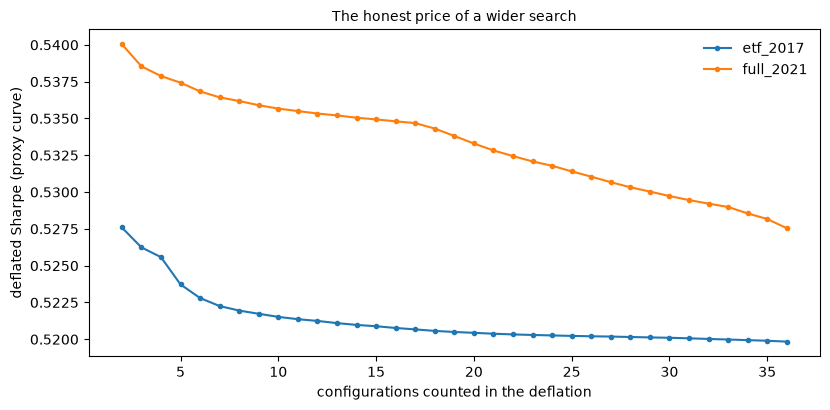

In [8]:
# The ledger is schema 2: every trial is a dict, and the ML hyperparameter grid is
# now recorded alongside the portfolio-lever grid. Schema 1 counted only the levers,
# understating the search — the deflation below is against the honest N.
from scipy.stats import norm

fig, ax = plt.subplots(figsize=(8.4, 4.2))
for uni in RESULTS:
    trials = LEDGER[uni]
    sharpes = [t["per_period_sharpe"] for t in trials if t.get("per_period_sharpe") is not None]
    cand = max(sharpes)
    ns, curve = list(range(2, len(sharpes) + 1)), []
    for n in ns:
        sub = sorted(sharpes, reverse=True)[:n]
        var = np.var(sub, ddof=1)
        sr_star = np.sqrt(var) * ((1 - 0.5772) * norm.ppf(1 - 1/n)
                                  + 0.5772 * norm.ppf(1 - 1/(n * np.e)))
        curve.append(float(norm.cdf(cand - sr_star)))
    ax.plot(ns, curve, marker="o", ms=3, label=uni)

    kinds = RESULTS[uni]["search_ledger"]["n_by_kind"]
    print(f"{uni:10s} N total {RESULTS[uni]['search_ledger']['n_trials_total']:3d} {kinds} | "
          f"{len(sharpes)} carry a Sharpe | reported DSR "
          f"{RESULTS[uni]['best_tuned_dsr_vs_search']}")

ax.set_xlabel("configurations counted in the deflation")
ax.set_ylabel("deflated Sharpe (proxy curve)")
ax.set_title("The honest price of a wider search", fontsize=10)
ax.legend(frameon=False); plt.tight_layout(); plt.show()


**Two things the cell above makes explicit.**

The search is larger than it used to be recorded as. The ledger now includes the ML hyperparameter
grid, which schema 1 omitted entirely — it counted only the portfolio-lever trials. That omission
understated N and therefore deflated *less* than it should have, in the project's own favour. The
counts printed above are the honest ones.

An IC-scored hyperparameter configuration has no portfolio return series, so it contributes to N
but not to the Sharpe pool the deflation's variance term uses. Those two numbers differ on purpose;
collapsing them would corrupt the variance estimate.

The CV information coefficients remain small in absolute terms, as return prediction usually is.
They are printed per fold in §2 rather than summarised, because a mean cannot distinguish a steady
weak signal from one fold carrying the average.


## 6. Summary — what Phase 5 establishes, and what it does not (P1–P4)

**Stated once, from the artifacts rather than from memory:** under strictly forward-only selection,
with the difference tested directly, **no signal model establishes outperformance** — not against
the regime baseline, not against equal weighting, on neither universe. Every paired interval printed
in §4 contains zero.

That is *not* a finding of equivalence. Failing to reject is not accepting the null, and no
equivalence test against a pre-specified margin was run.

**Why this is a result rather than a disappointment.** The EURAFRIC brief asked for *"une attention
particulière portée à la robustesse, au risque de surapprentissage"*. The machinery that can detect
the absence of an edge is the deliverable: forward-only folds whose geometry is published, a paired
test of the difference rather than two marginal intervals, a search count that includes the
hyperparameter grid, and a multiple-testing correction that reports itself as *not established*
instead of approximating one.

The clearest single demonstration is in §4: on one universe a tuned model beats the baseline on
point estimate — and the results artifact still records that boolean — while the paired test places
the difference nowhere near a threshold. Without this test, that ranking is what would have been
reported.
